# Spatial analysis of connectivity in the GBR


## Checking Shapefiles
I start by analyzing the shapefile and its components to ensure that they meet the necessary requirements for the analysis. This includes looking at the centroids and their corresponding IDs. The maps we are working with are based on different methods for dividing the area, specifically those from the Great Barrier Reef Marine Park Authority (GBRMPA) and the Australian Institute of Marine Science (AIMS). To provide a comprehensive overview, I have combined both approaches. This integration involves using the area delineations from AIMS and further dividing these areas into inshore and offshore regions. This method allows for a more detailed and nuanced representation of the spatial data.

/tmp/ipykernel_19585/1921908235.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf['geometry'].centroid


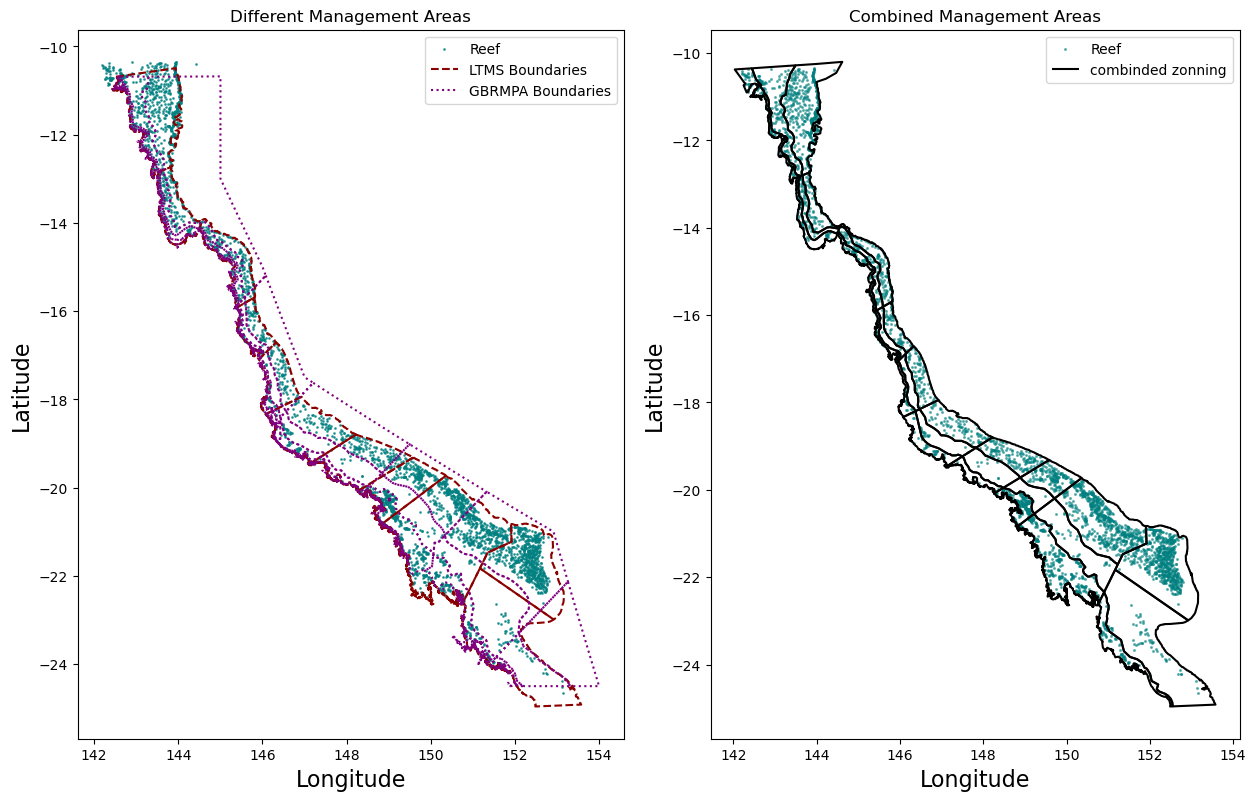

In [9]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the shapefile
gdf = gpd.read_file('../datasets/shapefiles/gbr1_coral_1m_merged.shp')
gdf2 = gpd.read_file('../datasets/shapefiles/AIMS_shapefile/ltms.shp')
gdf3 = gpd.read_file('../datasets/shapefiles/ereefs-scientific-consensus-wq-plots-2023-main/src-data/GBR_NRM-Waters/Polys.shp')
gdf4 = gpd.read_file('../datasets/shapefiles/AIMS_shapefile/Simplified_LTMS_AIMS.shp')
# Calculate the centroids of the geometries in gdf
centroids = gdf['geometry'].centroid

# Create a new figure and axis with subplots
fig, axs = plt.subplots(1, 2, figsize=(13, 8))  # Adjust figsize to desired dimensions
#plt.subplots_adjust(wspace=0)  # Adjust wspace here

# first subplot: MTMS and GBRMPA polygos 
centroids.plot(ax=axs[0], color='teal', markersize=1, label='Reef',alpha=0.7)  # Plot centroids on top
gdf2.boundary.plot(ax=axs[0], color='darkred', linewidth=1.5, linestyle='--', label='LTMS Boundaries')
gdf3.boundary.plot(ax=axs[0], color='purple', linewidth=1.5, linestyle=':', label='GBRMPA Boundaries')

axs[0].set_title('Different Management Areas')
axs[0].legend()
axs[0].set_xlabel('Longitude',fontsize=16)
axs[0].set_ylabel('Latitude',fontsize=16)

# First subplot: Plot gdf polygons and centroids
centroids.plot(ax=axs[1], color='teal', markersize=1.5, label='Reef',alpha=0.5)  # Plot centroids on top
gdf4.boundary.plot(ax=axs[1], color='black', linewidth=1.5, label='combinded zonning')
axs[1].set_title('Combined Management Areas')
axs[1].legend()
# Show the plot
plt.tight_layout()
axs[1].set_xlabel('Longitude',fontsize=16)
axs[1].set_ylabel('Latitude',fontsize=16)
plt.savefig(f'/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/figures/maps.png')
plt.show()


## Mapping reefs to management areas

In this step, I perform a spatial analysis of the different shapefiles. This transforms and joins spatial data to map centroids of geometric shapes from one dataset to another. In this way, I map the index used to create the connectivity matrices (gbr1_coral_1m_merged_buffer0p001.shp). Then, the idea is to map all the polygons' Feature unique identifiers (FIDs) to the FIDs of our new Management polygons (see step before).

In [10]:
import pandas as pd
import geopandas as gpd

# Load the shapefiles
gdf = gpd.read_file('../datasets/shapefiles/gbr1_coral_1m_merged_buffer0p001.shp')
GBR_gdf = gpd.read_file('../datasets/shapefiles/AIMS_shapefile/Simplified_LTMS_AIMS.shp')

# Define the projected CRS (ensure it's suitable for your area)
projected_crs = 'EPSG:28355'  # GDA94 / MGA zone 55, 
# Re-project both GeoDataFrames to the chosen projected CRS
gdf_projected = gdf.to_crs(projected_crs)
GBR_gdf_projected = GBR_gdf.to_crs(projected_crs)
# Calculate centroids on the projected GeoDataFrame
gdf_projected['centroids'] = gdf_projected['geometry'].centroid
# If needed, add these centroids back to the original GeoDataFrame, re-projecting them to the original CRS
gdf['centroids'] = gdf_projected['centroids'].to_crs(gdf.crs)

# Perform a spatial join to find Coral polygons within LTMS polygons
joined_gdf = gpd.sjoin(gdf_projected, GBR_gdf_projected, how="inner", predicate='within')
# Extract the columns of interest
mapping_index = joined_gdf[['FID_left', 'FID_right']]
mapping_index = mapping_index.rename(columns={'FID_left': 'coral_id', 'FID_right': 'ltms_id'})

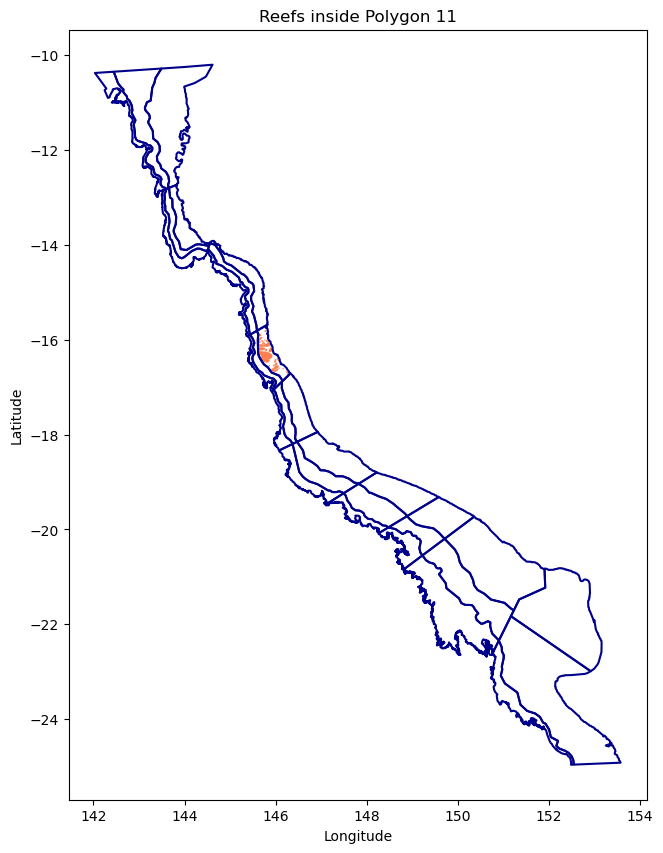

In [11]:
# I would like to plot one polygn and all the reefs insde it using the combined_index
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
polygon_id = 11
polygon_gdf = GBR_gdf[GBR_gdf['FID'] == polygon_id]
# Assuming 'combined_index' maps reef IDs ('coral_id') to polygon IDs ('ltms_id')
reef_ids_in_polygon = mapping_index[mapping_index['ltms_id'] == polygon_id]['coral_id']
# Filter the reefs GeoDataFrame to only include reefs inside the selected polygon
reefs_in_polygon_gdf = gdf[gdf['FID'].isin(reef_ids_in_polygon)]

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
# Plot the selected polygon
gdf4.boundary.plot(ax=ax, color='darkblue', linewidth=1.5, label='Simplified LTMS AIMS')

# Plot the reefs inside the selected polygon
reefs_in_polygon_gdf.plot(ax=ax, color='coral', markersize=15, label='Reefs')

# Enhancements
plt.title(f'Reefs inside Polygon {polygon_id}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
# Load the shapefiles

## Assigning Out-of-Boundary Reefs to Polygons
In this step, we assign all out-of-boundary reefs to their respective polygons. Although few reefs are located outside the boundaries, they must still be assigned to a specific polygon. To accomplish this, I calculate the distance between the centroid of each out-of-boundary reef and all the polygons. Each reef is then assigned to the polygon with the shortest distance.

Number of missing features: 616


/tmp/ipykernel_19585/1856966262.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = missing_features['geometry'].centroid


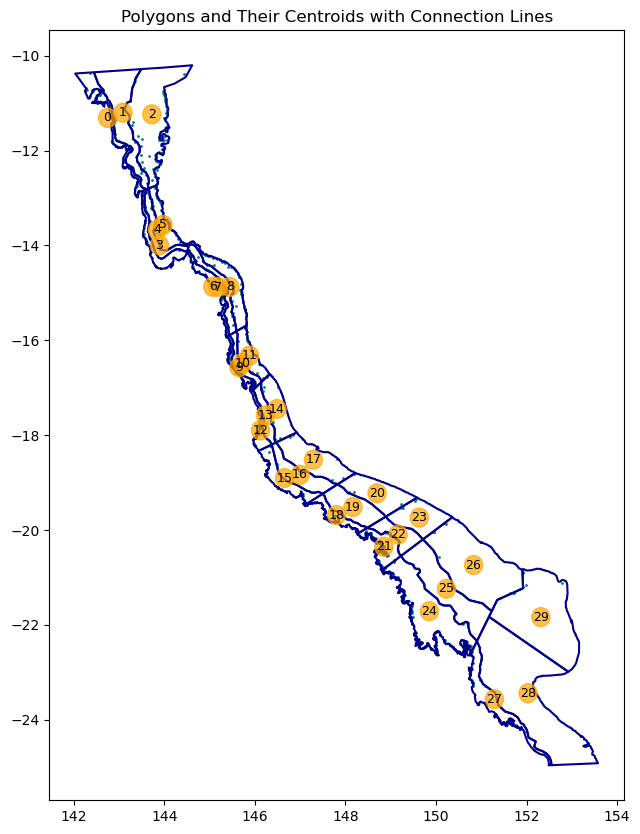

In [12]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString
from matplotlib.patches import Circle
from util_tools import *
## create a new copy of the GBR_gdf
GBR_gdf_index = GBR_gdf_projected.copy()
# # Find the indices of 'gdf' (reefs) that are not in 'joined_gdf'
missing_features = find_missing_features(gdf_projected, joined_gdf)
# Assign the closest polygon to each missing feature
assign_closest_polygon(missing_features, GBR_gdf_index)

new_missing=missing_features[missing_features['closest_polygon_index']== 2]
## projecting back the features
missing_features['geometry'] = missing_features['geometry'].to_crs(gdf.crs)
GBR_gdf_index['geometry'] = GBR_gdf_index['geometry'].to_crs(gdf.crs)
## Plot the polygons
fig, ax = plt.subplots(figsize=(10, 10))
gdf4.boundary.plot(ax=ax, color='darkblue', linewidth=1.5, label='Simplified LTMS AIMS')
# Plot centroids of missing features
#centroids = missing_features.centroid
centroids = missing_features['geometry'].centroid
centroids.plot(ax=ax, color='teal', markersize=1, label='Centroids',alpha=1)  # Plot centroids on top

# For each missing feature, plot a line to the centroid of the closest polygon
for index, row in missing_features.iterrows():
    # Retrieve the centroid of the missing feature
    missing_feature_centroid = row.geometry.centroid
    # Retrieve the centroid of the closest polygon
    index = GBR_gdf_index.index[GBR_gdf_index['FID'] == row['closest_polygon_index']].item()
    closest_polygon_centroid = GBR_gdf_index.loc[index].geometry.centroid
    # closest_polygon_centroid = GBR_gdf_index[GBR_gdf_index['FID'] == row['closest_polygon_index']].geometry.centroid.iloc[0]
    # Create a line connecting the missing feature centroid and the closest polygon centroid
    line = LineString([missing_feature_centroid, closest_polygon_centroid])
    
# Add FID to the polygons at the centroid location with a circle background
for index, row in GBR_gdf_index.iterrows():
    centroid = row.geometry.centroid
    fid = row['FID']
    # Create a circle patch as the background for the FID text
    circle = Circle((centroid.x, centroid.y), 0.2, color='orange', alpha=0.7, zorder=2)
    ax.add_patch(circle)
    # Print fid and index with the circle background
    ax.text(centroid.x, centroid.y, str(fid), fontsize=9, ha='center', va='center', zorder=3)

# Enhance the plot
plt.title('Polygons and Their Centroids with Connection Lines')
plt.show()

## Index Mapping File
During this step, we will generate a file that maps the reefs to the new management areas. This file is crucial for clarifying the connectivity results from the connectivity matrix and will also expedite the calculations.

In [ ]:
import pandas as pd
# Assuming missing_features and mapping_index are defined earlier in your code
missing_index = missing_features[['FID', 'closest_polygon_index']]
missing_index = missing_index.rename(columns={'FID': 'coral_id', 'closest_polygon_index': 'ltms_id'})

# Combine mapping_index and missing_index into a new DataFrame
combined_index = pd.concat([mapping_index, missing_index], ignore_index=True)

# Save the new combined DataFrame to a different file
combined_index.to_csv('/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/reefs/combined_mapping_index.txt', sep='\t', index=False)


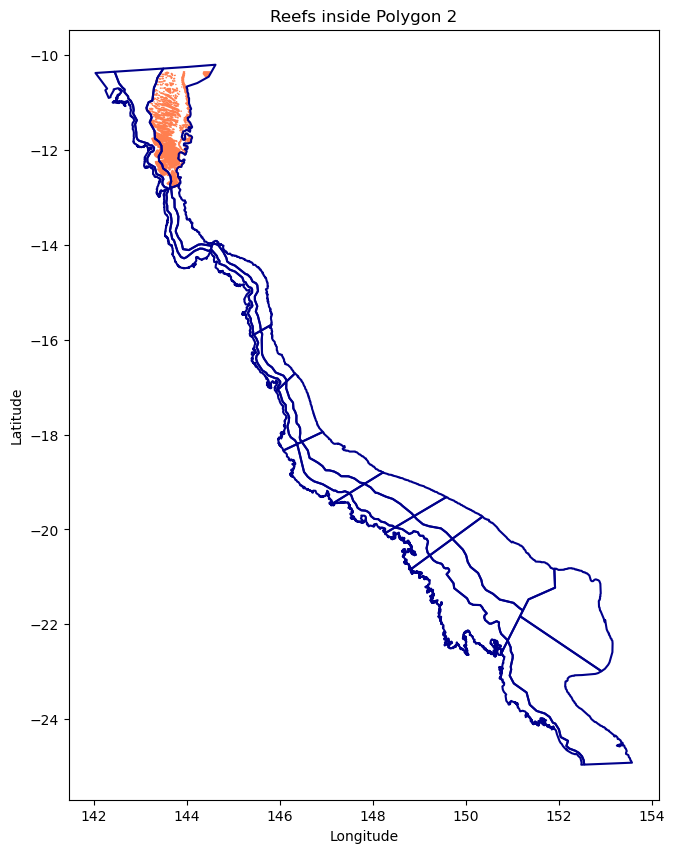

In [ ]:
# I would like to plot one polygn and all the reefs insde it using the combined_index
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
polygon_id = 2
polygon_gdf = GBR_gdf[GBR_gdf['FID'] == polygon_id]
# Assuming 'combined_index' maps reef IDs ('coral_id') to polygon IDs ('ltms_id')
reef_ids_in_polygon = combined_index[combined_index['ltms_id'] == polygon_id]['coral_id']
# Filter the reefs GeoDataFrame to only include reefs inside the selected polygon
reefs_in_polygon_gdf = gdf[gdf['FID'].isin(reef_ids_in_polygon)]

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
# Plot the selected polygon
gdf4.boundary.plot(ax=ax, color='darkblue', linewidth=1.5, label='Simplified LTMS AIMS')

# Plot the reefs inside the selected polygon
reefs_in_polygon_gdf.plot(ax=ax, color='coral', markersize=15, label='Reefs')

# Enhancements
plt.title(f'Reefs inside Polygon {polygon_id}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
# Load the shapefiles




# Connectivity Analysis
In this section we will analyse the connectivity matrices by MAnagement area to look for temporal or spatial patterns in the data.
## Calculating the probability of connection by each source area during all the years: Given a dataset with connectivity values between sources and targets, the probability of connection from a specific source to any target is calculated by:

1- Summing Connectivity Values Across Targets for Each Source:

- Let $(C_{ij})$ be the connectivity value from source ($i$) to target ($j$).
The sum of connectivity values for source (i) across all targets is given by: $[S_i = \sum_{j} C_{ij}]$
Calculating Total Connectivity Across All Sources:

- The total sum of connectivity values across all sources and targets is: $[ T = \sum_{i} S_i ]$

2- Calculating Probability of Connection for Each Source:

The probability of connection from source ($i$), denoted as ($P_i$), is calculated by normalizing the sum of connectivity values for source (i) by the total connectivity: $[ P_i = \frac{S_i}{T} ]$
This results in a probability distribution over sources, indicating the relative likelihood of connection from each source to any target, based on the connectivity values.

- In summary, the mathematical formula for calculating the probability of connection for a source ($i$) is: $[ P_i = \frac{\sum_{j} C_{ij}}{\sum_{i} \sum_{j} C_{ij}} ]$

/tmp/ipykernel_19585/853262926.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='source', y='probability', data=mean_probabilities, palette=colors, ax=axs[0])
/tmp/ipykernel_19585/853262926.py:36: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(x='source', y='probability', data=mean_probabilities, palette=colors, ax=axs[0])


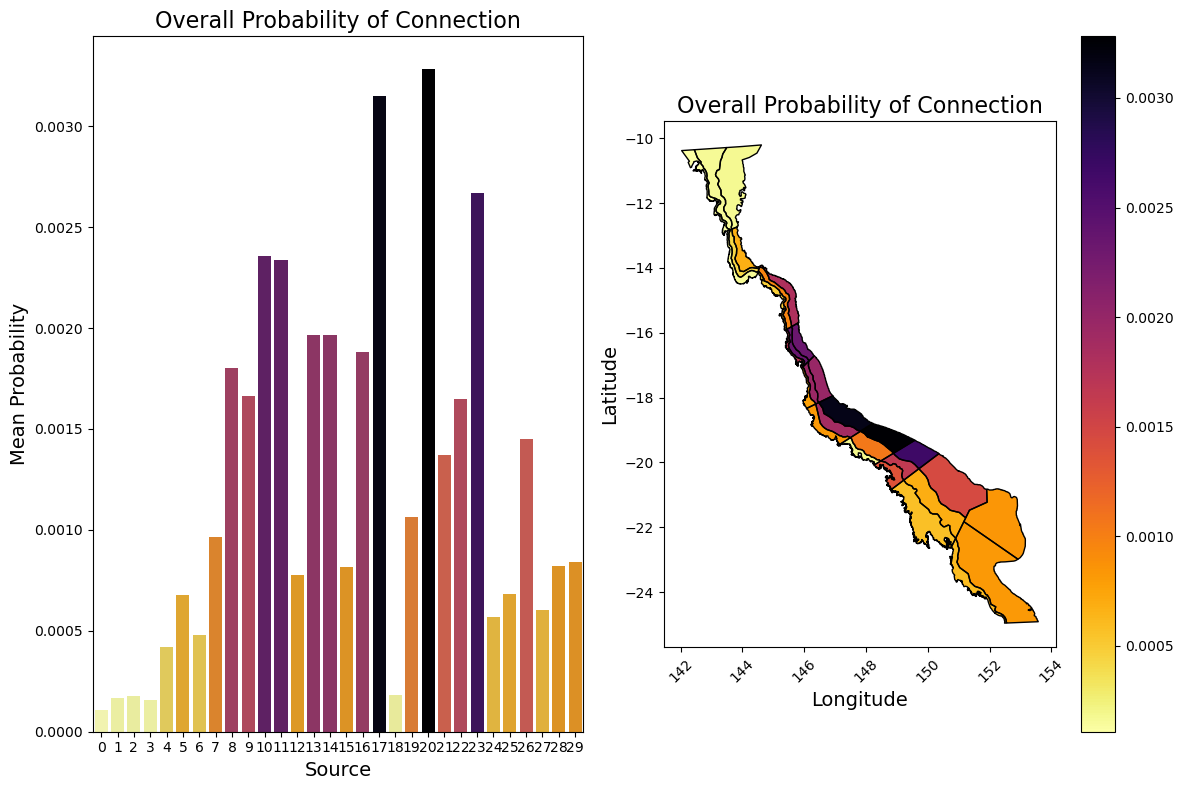

In [4]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
nc_dataset=xr.open_dataset('/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/connectivity_matrices/connectivity_merulinidae_single_by_area.nc')
# Sum connectivity values across a dimension, e.g., 'target'
connectivity_sum = nc_dataset['connectivity'].sum(dim='sink')

# Convert sums to probabilities
total_connectivity = connectivity_sum.sum()
probabilities = connectivity_sum / total_connectivity

# Convert to pandas DataFrame for plotting
prob_df = probabilities.to_dataframe(name='probability').reset_index()
# calculate the mean probability of connection by source
mean_probabilities = prob_df.groupby('source')['probability'].mean().reset_index()
# using this probablilities we can plot the probability of connection by source using the shapefile
# Set a color palette for the plot
# Ensure 'FID' is of the same type as 'source' in mean_probabilities for a successful merge
gdf4['FID'] = gdf4['FID'].astype(str)
mean_probabilities['source'] = mean_probabilities['source'].astype(str)

# Step 2: Merge the GeoDataFrame with mean_probabilities DataFrame
merged_gdf = gdf4.merge(mean_probabilities, left_on='FID', right_on='source')
# Step 3: Plot the merged data
# Create a combined figure with 1 row and 2 columns
# Step 1: Generate a color palette
# Normalize the probability values to get a range between 0 and 1
prob_normalized = (mean_probabilities['probability'] - mean_probabilities['probability'].min()) / (mean_probabilities['probability'].max() - mean_probabilities['probability'].min())
colors = sns.color_palette("inferno_r", as_cmap=True)(prob_normalized)

# Step 2: Use the mapped colors in the bar plot
fig, axs = plt.subplots(1, 2, figsize=(12, 8))

# Plot the bar plot of mean probabilities on the second subplot with colors based on probability
sns.barplot(x='source', y='probability', data=mean_probabilities, palette=colors, ax=axs[0])
axs[0].set_title('Overall Probability of Connection', fontsize=16)
axs[0].set_xlabel('Source', fontsize=14)
axs[0].set_ylabel('Mean Probability', fontsize=14)
plt.xticks(rotation=45)  # Rotate the x-axis labels for better readability

# Plot the spatial distribution on the first subplot
merged_gdf.plot(column='probability', cmap='inferno_r', legend=True, ax=axs[1])
axs[1].set_title('Overall Probability of Connection', fontsize=16)
# Then, plot the boundaries by plotting the geometries again without specifying 'column'
merged_gdf.boundary.plot(ax=axs[1], edgecolor='black', linewidth=1)

axs[1].set_xlabel('Longitude', fontsize=14)
axs[1].set_ylabel('Latitude', fontsize=14)



plt.tight_layout()  # Adjust the layout to make room for the rotated x-axis labels
## save plot
plt.savefig(f'/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/figures/overall_probability_of_connection.png')
plt.show()

# #plt.cm.inferno_r


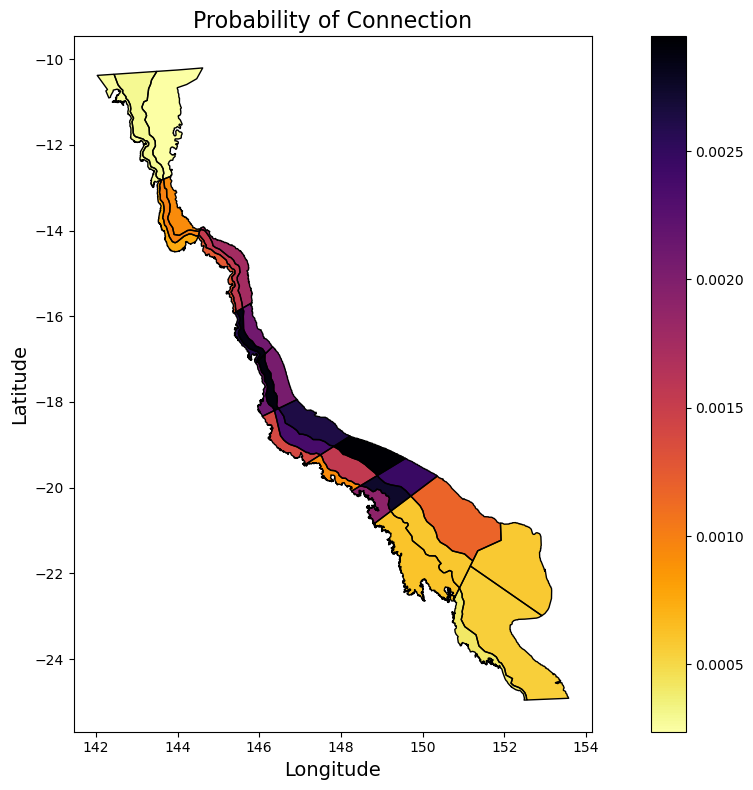

In [7]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
nc_dataset = xr.open_dataset('/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/connectivity_matrices/old_connectivity_matrices.nc')
# Sum connectivity values across a dimension, e.g., 'target'
connectivity_sum = nc_dataset['connectivity'].sum(dim='target')

# Convert sums to probabilities
total_connectivity = connectivity_sum.sum()
probabilities = connectivity_sum / total_connectivity

# Convert to pandas DataFrame for plotting
prob_df = probabilities.to_dataframe(name='probability').reset_index()
# calculate the mean probability of connection by source
mean_probabilities = prob_df.groupby('source')['probability'].mean().reset_index()
# using these probabilities we can plot the probability of connection by source using the shapefile
# Ensure 'FID' is of the same type as 'source' in mean_probabilities for a successful merge
gdf4['FID'] = gdf4['FID'].astype(str)
mean_probabilities['source'] = mean_probabilities['source'].astype(str)

# Merge the GeoDataFrame with mean_probabilities DataFrame
merged_gdf = gdf4.merge(mean_probabilities, left_on='FID', right_on='source')

# Plot the spatial distribution
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the filled areas based on 'probability'
merged_gdf.plot(column='probability', cmap='inferno_r', legend=True, ax=ax)
ax.set_title('Probability of Connection', fontsize=16)

# Then, plot the boundaries by plotting the geometries again without specifying 'column'
merged_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=1)

ax.set_xlabel('Longitude', fontsize=14)
ax.set_ylabel('Latitude', fontsize=14)

plt.tight_layout()  # Adjust the layout
# Save plot
plt.savefig(f'/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/figures/single_overall_probability_of_connection_map.png')
plt.show()

## Connectivity Arrays
After mapping the 3806 reefs to their respective management areas, I created a NetCDF file containing all the connectivity matrices from 2015 to 2022. With this data, we can perform various analyses to understand the dynamics of raw connectivity within the system.

(30, 30)


IndexError: single positional indexer is out-of-bounds

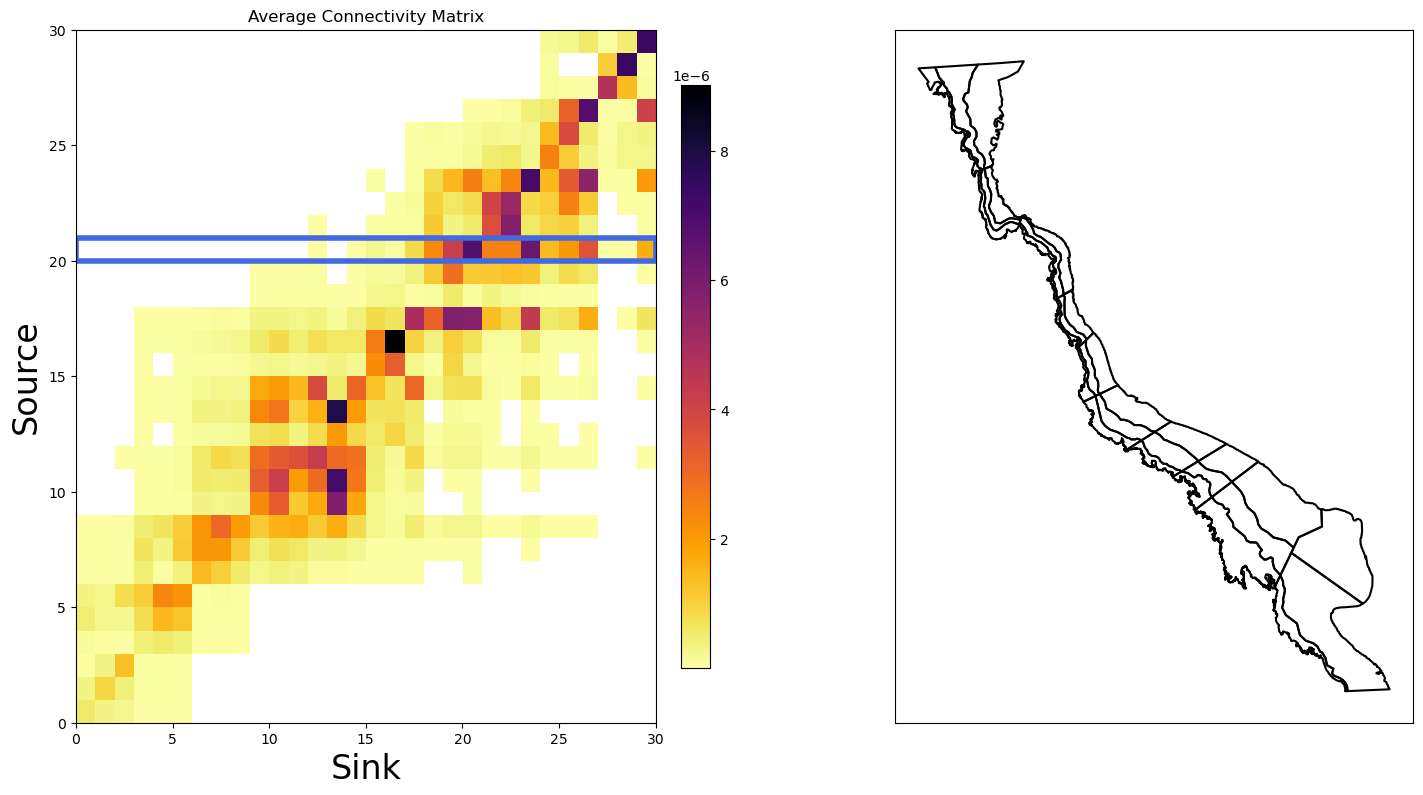

In [14]:
## loading netcdf with the connectivity matrices:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from matplotlib.patches import Circle
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
from shapely.geometry import LineString


nc_dataset=xr.open_dataset('/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/connectivity_matrices/connectivity_merulinidae_single_by_area.nc')
#Slice the dataset connectivity in (time=1, source= all, sink=all, treatment=1,sample=1)
#nc_dataset_slice=nc_dataset.isel(time=slice(0,3), source=slice(0,3806), sink=slice(0,3806), treatment=0,sample=0)
# Step 1: Calculate the Average Connectivity Matrix over all time steps
average_connectivity_matrix = nc_dataset.mean(dim='time').to_array()[0]
average_connectivity_matrix_flipped = np.flipud(average_connectivity_matrix)
print(average_connectivity_matrix_flipped.shape)
# Step 2: Calculate the Variance of the Connectivity Matrix over all time steps
variance_connectivity_matrix = nc_dataset.var(dim='time').to_array()[0]
variance_connectivity_matrix_flipped = np.flipud(variance_connectivity_matrix)
# For demonstration, let's assume they are:
n_rows, n_cols = average_connectivity_matrix.shape

# Create masked arrays where zeros are masked
average_connectivity_matrix_masked = np.ma.masked_where(average_connectivity_matrix_flipped == 0, average_connectivity_matrix_flipped)
variance_connectivity_matrix_masked = np.ma.masked_where(variance_connectivity_matrix_flipped == 0, variance_connectivity_matrix_flipped)
# For the Map
polygon_id = 20  # Example polygon ID
# Assuming GBR_gdf and gdf4 are already defined and contain the necessary geographic data
# Re-project GeoDataFrames to a projected CRS (e.g., World Mercator for global scope)
projected_crs = 'EPSG:3395'  # World Mercator
polygon_gdf_projected = GBR_gdf[GBR_gdf['FID'] == polygon_id].to_crs(projected_crs)
gdf4_projected = gdf4.to_crs(projected_crs)

# Step 1: Extract the Centroid of Polygon 19 in the projected CRS
polygon_centroid = polygon_gdf_projected.centroid.iloc[0]

# Step 2: Find Non-Zero Elements in the row for Reef 19
connected_reefs_indices = np.nonzero(average_connectivity_matrix_flipped[:, polygon_id])[0]

connected_reefs_indices2 = np.nonzero(average_connectivity_matrix_flipped[polygon_id, :])[0]

connected_polygons_gdf = gdf4_projected[gdf4_projected['FID'].isin(connected_reefs_indices)]
value_connected_reefs = np.log1p(average_connectivity_matrix_flipped[connected_reefs_indices,polygon_id])
# scale values from 0-1
value_connected_reefs = value_connected_reefs/value_connected_reefs.max()

# Use the reversed inferno colormap
inferno_reversed_cmap = plt.cm.inferno_r

# Prepare the figure and axes for plotting
fig, axs = plt.subplots(1, 2, figsize=(18, 9))  # Adjust figsize as needed

# Plot Average Connectivity Matrix with reversed inferno gradient
cax1 = axs[0].imshow(average_connectivity_matrix_masked, cmap=inferno_reversed_cmap, aspect='auto', extent=[0, n_cols, 0, n_rows])
fig.colorbar(cax1, ax=axs[0], fraction=0.046, pad=0.04)
# Adjust the rectangle to cover all columns on the row corresponding to polygon_id in a flipped matrix
highlight_rect = Rectangle((0, polygon_id), n_cols, 1, edgecolor='royalblue', facecolor='none', lw=4)
axs[0].add_patch(highlight_rect)

axs[0].set_title('Average Connectivity Matrix')
axs[0].set_xlabel('Sink', fontsize=24)
axs[0].set_ylabel('Source', fontsize=24)

# Plot Map with Polygon and Connections
gdf4_projected.boundary.plot(ax=axs[1], color='black', linewidth=1.5, label='Simplified LTMS AIMS')
#polygon_gdf_projected.boundary.plot(ax=ax, color='darkblue', marker='o', markersize=10, label=f'Polygon {polygon_id} Centroid')


# Hide the axes labels
axs[1].set_xticklabels([])
axs[1].set_yticklabels([])
axs[1].tick_params(axis='both', which='both', length=0)

# Reuse the reversed inferno colormap for plotting lines
norm = Normalize(vmin=0, vmax=len(connected_reefs_indices)-1)
sm = ScalarMappable(norm=norm, cmap=inferno_reversed_cmap)

# Plot the centroid of the selected polygons from the connectivity matrix
for index in range(len(connected_reefs_indices)):
    reef_ide_connected = connected_reefs_indices[index].astype(str)
    connected_reef_centroid = gdf4_projected[gdf4_projected['FID'] == reef_ide_connected].centroid.iloc[0]
    color = sm.to_rgba(index)
    axs[1].plot([polygon_centroid.x, connected_reef_centroid.x], [polygon_centroid.y, connected_reef_centroid.y], color=color, alpha=value_connected_reefs[index])

axs[1].text(0.95, 0.95, f'Polygon {polygon_id}', transform=axs[1].transAxes, horizontalalignment='right', verticalalignment='top', fontsize=24, color='red')

plt.tight_layout()
#sve file
plt.savefig(f'/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/figures/average_connectivity_matrix.png')
plt.show()


## Temporal Network Analysis
a. Time Series Analysis

- Calculate network metrics over time: Compute network metrics (e.g., average degree, clustering coefficient, betweenness centrality) for each time point and analyze how these metrics evolve.

- Trend analysis: Use statistical methods to identify trends and patterns in the network metrics over time.

- Autocorrelation: Examine the autocorrelation of network metrics to understand the temporal dependencies.

b. Sliding Window Analysis

- Window-based metrics: Use a sliding window approach to compute network metrics over a specified time window, then slide the window across the entire time series to observe changes.
- Cross-correlation: Compute the cross-correlation between different nodes or sub-networks within each window to detect dynamic interactions.


/tmp/ipykernel_19585/2608087740.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend()
/tmp/ipykernel_19585/2608087740.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 1].legend()
/tmp/ipykernel_19585/2608087740.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 1].legend()
/tmp/ipykernel_19585/2608087740.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1, 0].legend()


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/network_metrics_over_time.png'

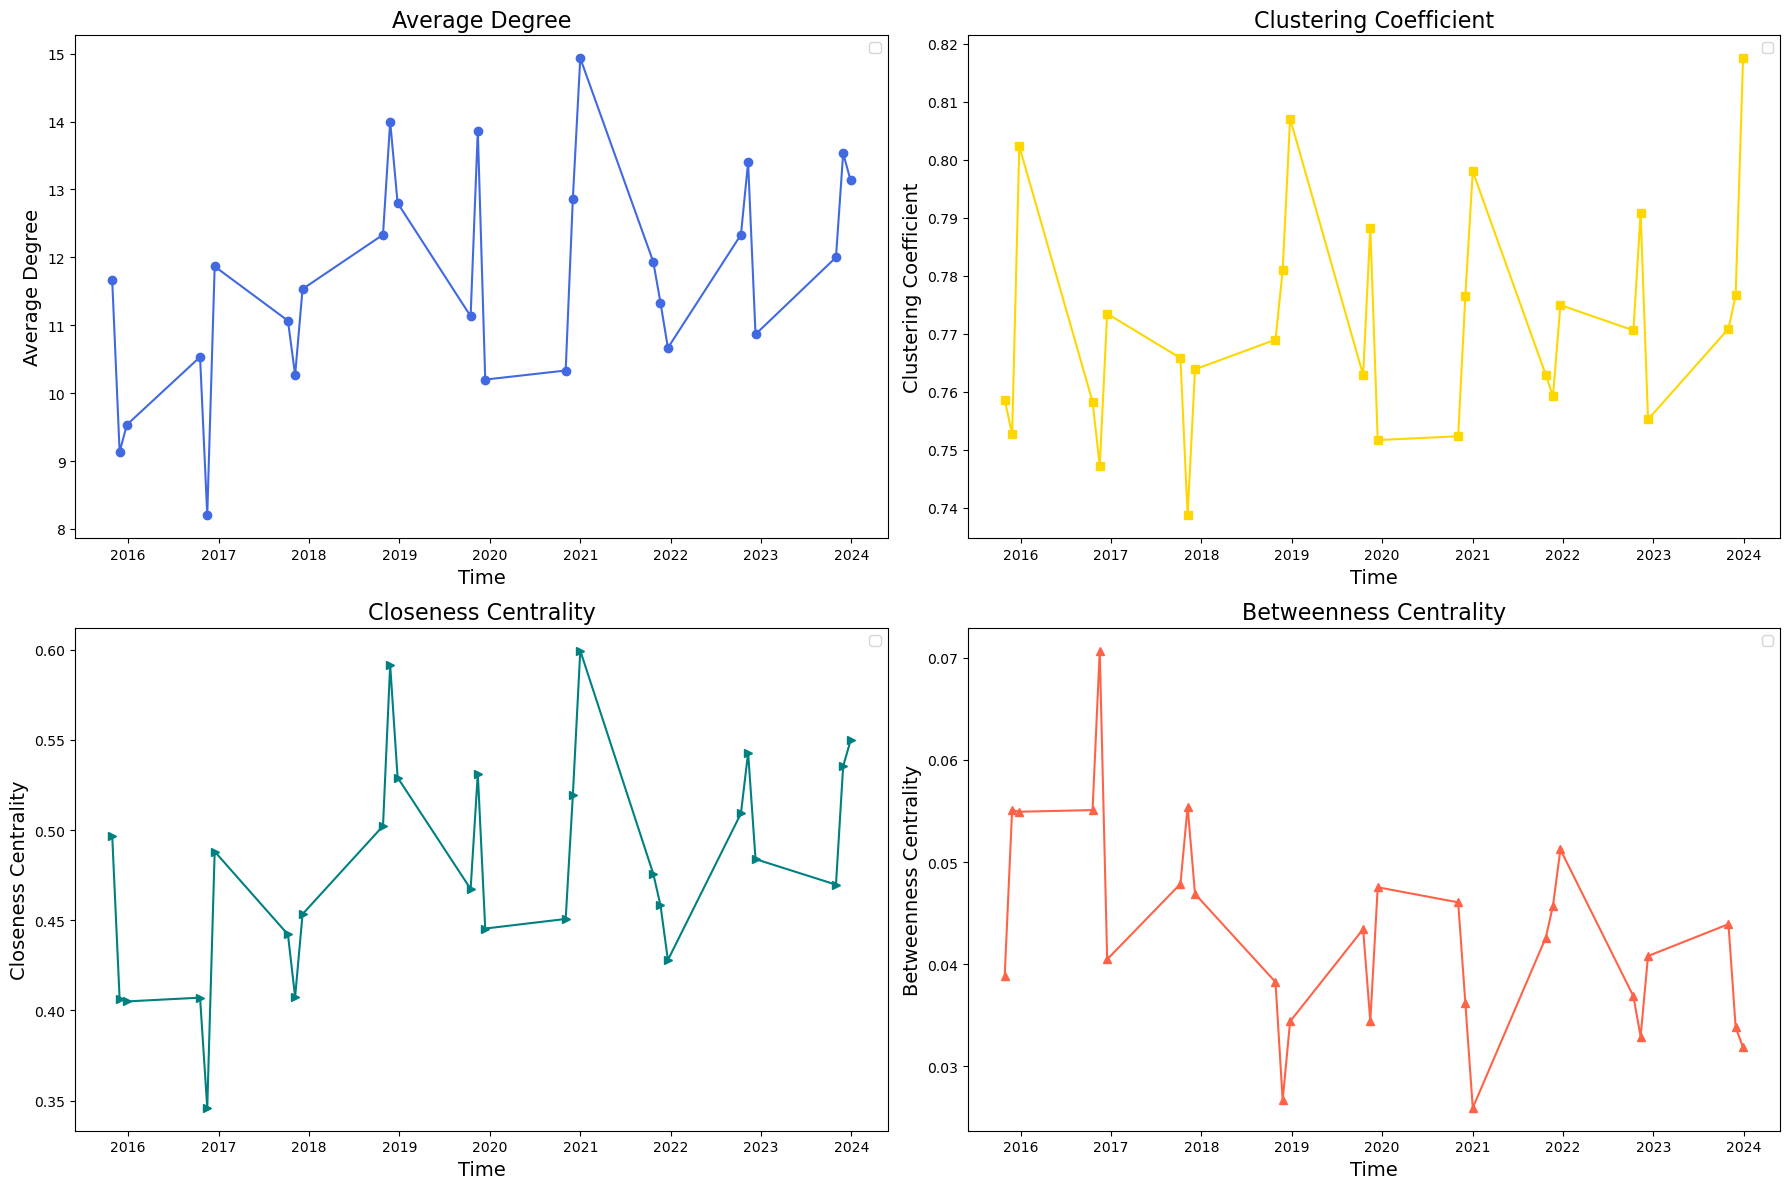

In [15]:
import numpy as np
import pandas as pd
import networkx as nx

metrics_over_time = []
# Assuming 'nc_dataset' is already defined and imported along with necessary libraries
for time_point in nc_dataset.time:
    matrix = nc_dataset['connectivity'].sel(time=time_point).values
    G = nx.from_numpy_array(matrix)
    
    # Existing metrics
    avg_degree = np.mean([degree for node, degree in G.degree()])
    clustering_coeff = nx.average_clustering(G)
    betweenness_centrality = np.mean(list(nx.betweenness_centrality(G).values()))
    
    # New metrics
    # Closeness Centrality
    closeness_centrality = np.mean(list(nx.closeness_centrality(G).values()))
    # Append metrics for this time point
    metrics_over_time.append({
        'time': time_point.values,
        'average_degree': avg_degree,
        'clustering_coefficient': clustering_coeff,
        'betweenness_centrality': betweenness_centrality,
        'closeness_centrality': closeness_centrality,
    })
# Convert to DataFrame for easier analysis
metrics_df = pd.DataFrame(metrics_over_time)
metrics_df.sort_values(by='time', inplace=True)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))  # Adjusted for 2 rows, 3 columns
# Plot Average Degree
# Plot Average Degree
axes[0, 0].plot(metrics_df['time'], metrics_df['average_degree'], marker='o', color='royalblue')
axes[0, 0].set_title('Average Degree', fontsize=16)
axes[0, 0].set_xlabel('Time', fontsize=14)  # Increased font size
axes[0, 0].set_ylabel('Average Degree', fontsize=14)  # Increased font size
axes[0, 0].legend()

# Plot Clustering Coefficient
axes[0, 1].plot(metrics_df['time'], metrics_df['clustering_coefficient'], marker='s', color='gold')
axes[0, 1].set_title('Clustering Coefficient', fontsize=16)
axes[0, 1].set_xlabel('Time', fontsize=14)  # Increased font size
axes[0, 1].set_ylabel('Clustering Coefficient', fontsize=14)  # Increased font size
axes[0, 1].legend()

# Plot Betweenness Centrality
axes[1, 1].plot(metrics_df['time'], metrics_df['betweenness_centrality'], marker='^', color='tomato')
axes[1, 1].set_title('Betweenness Centrality', fontsize=16)
axes[1, 1].set_xlabel('Time', fontsize=14)  # Increased font size
axes[1, 1].set_ylabel('Betweenness Centrality', fontsize=14)  # Increased font size
axes[1, 1].legend()

# Plot Closeness Centrality
axes[1, 0].plot(metrics_df['time'], metrics_df['closeness_centrality'], marker='>', color='teal')
axes[1, 0].set_title('Closeness Centrality', fontsize=16)
axes[1, 0].set_xlabel('Time', fontsize=14)  # Increased font size
axes[1, 0].set_ylabel('Closeness Centrality', fontsize=14)  # Increased font size
axes[1, 0].legend()

plt.tight_layout()  # Adjust layout to not overlap
## save plot
plt.savefig(f'../outputs/network_metrics_over_time.png')
plt.show()

### Some basic analyses of the data

In [13]:
from scipy import stats

# Placeholder for results
trend_results = {}

# Analyze trends for each metric
for metric in ['average_degree', 'clustering_coefficient', 'betweenness_centrality', 'closeness_centrality']:
    slope, intercept, r_value, p_value, std_err = stats.linregress(metrics_df.index, metrics_df[metric])
    trend_results[metric] = {'slope': slope, 'p_value': p_value}

# Display results
for metric, result in trend_results.items():
    print(f"{metric}: Slope = {result['slope']:.4f}, P-value = {result['p_value']:.4f}")

average_degree: Slope = 0.0764, P-value = 0.1008
clustering_coefficient: Slope = 0.0017, P-value = 0.0672
betweenness_centrality: Slope = -0.0007, P-value = 0.0226
closeness_centrality: Slope = 0.0038, P-value = 0.0377


## In this step I will generate the same metrics but for each zone an year

In [14]:
import xarray as xr
import pandas as pd
import networkx as nx

# Load the NetCDF file
nc_dataset = xr.open_dataset('../outputs/connectivity_matrices.nc')

source_areas = nc_dataset['source'].values
years = nc_dataset['time'].values

# Initialize a DataFrame to store the metrics
metrics_df = pd.DataFrame(columns=['source_area', 'date', 'degree', 'clustering', 'betweenness', 'closeness'])

rows_to_add = []

for area in source_areas:
    for time_point in years:
        # Extract connectivity data for the current area and year
        matrix = nc_dataset['connectivity'].sel(time=time_point).values
        G = nx.from_numpy_array(matrix)
        # Calculate metrics for each node
        degrees = dict(G.degree())
        clustering_coefficients = nx.clustering(G)
        betweenness_centrality = nx.betweenness_centrality(G)
        closeness_centrality = nx.closeness_centrality(G)
        # For each node, store its metrics
        for node in G.nodes:
            row = {
                'source_area': node,
                'date': time_point,
                'degree': int(degrees[node]),
                'clustering': clustering_coefficients[node],
                'betweenness': betweenness_centrality[node],
                'closeness': closeness_centrality[node]
            }
            rows_to_add.append(row)

# Convert the list of rows to a DataFrame
new_rows_df = pd.DataFrame(rows_to_add)

# Concatenate the new rows to the original DataFrame
metrics_df = pd.concat([metrics_df, new_rows_df], ignore_index=True)

# Ensure to close the NetCDF dataset if you're done with it
nc_dataset.close()
# Convert 'date' to datetime format
metrics_df['date'] = pd.to_datetime(metrics_df['date'])
metrics_df['degree'] = pd.to_numeric(metrics_df['degree'], errors='coerce')

# Extract year from 'date'
metrics_df['year'] = metrics_df['date'].dt.year

# Group by 'source_area' and 'year', then calculate the mean for each group
average_metrics_df = metrics_df.groupby(['source_area', 'year']).mean().reset_index()
average_metrix_by_area = average_metrics_df.groupby('source_area').mean().reset_index()


/tmp/ipykernel_9299/1175592135.py:54: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  average_metrics_df = metrics_df.groupby(['source_area', 'year']).mean().reset_index()


### Metrics explanation:
1. **Degree**: This is the simplest and most straightforward metric. The degree of a node is the number of edges connected to it. In directed graphs, you can further distinguish between in-degree (number of incoming edges) and out-degree (number of outgoing edges). A higher degree indicates a more connected or important node within the network.

2. **Clustering Coefficient**: This metric measures the degree to which nodes in a graph tend to cluster together. Specifically, for a given node, the clustering coefficient is the ratio of existing links connecting its neighbors to each other to the maximum possible number of such links. The clustering coefficient ranges from 0 to 1. A higher value indicates a greater degree of clustering, suggesting that the node’s neighbors are also neighbors of each other.

3. **Betweenness Centrality**: This metric quantifies the number of times a node acts as a bridge along the shortest path between two other nodes. Nodes with high betweenness centrality may have considerable influence within a network by virtue of their control over information passing between others. They are often found in strategic positions within the network, connecting different clusters or groups.

4. **Closeness Centrality**: This metric measures how close a node is to all other nodes in the network. It is calculated as the inverse of the average shortest path length from the node to all other nodes. Nodes with high closeness centrality can quickly interact with all others because they are, on average, closer to them. This can indicate nodes that are able to spread information efficiently or reach others quickly.

Each of these metrics provides a different perspective on the role and importance of nodes within a network, helping to understand the structure and dynamics of complex systems modeled as graphs.

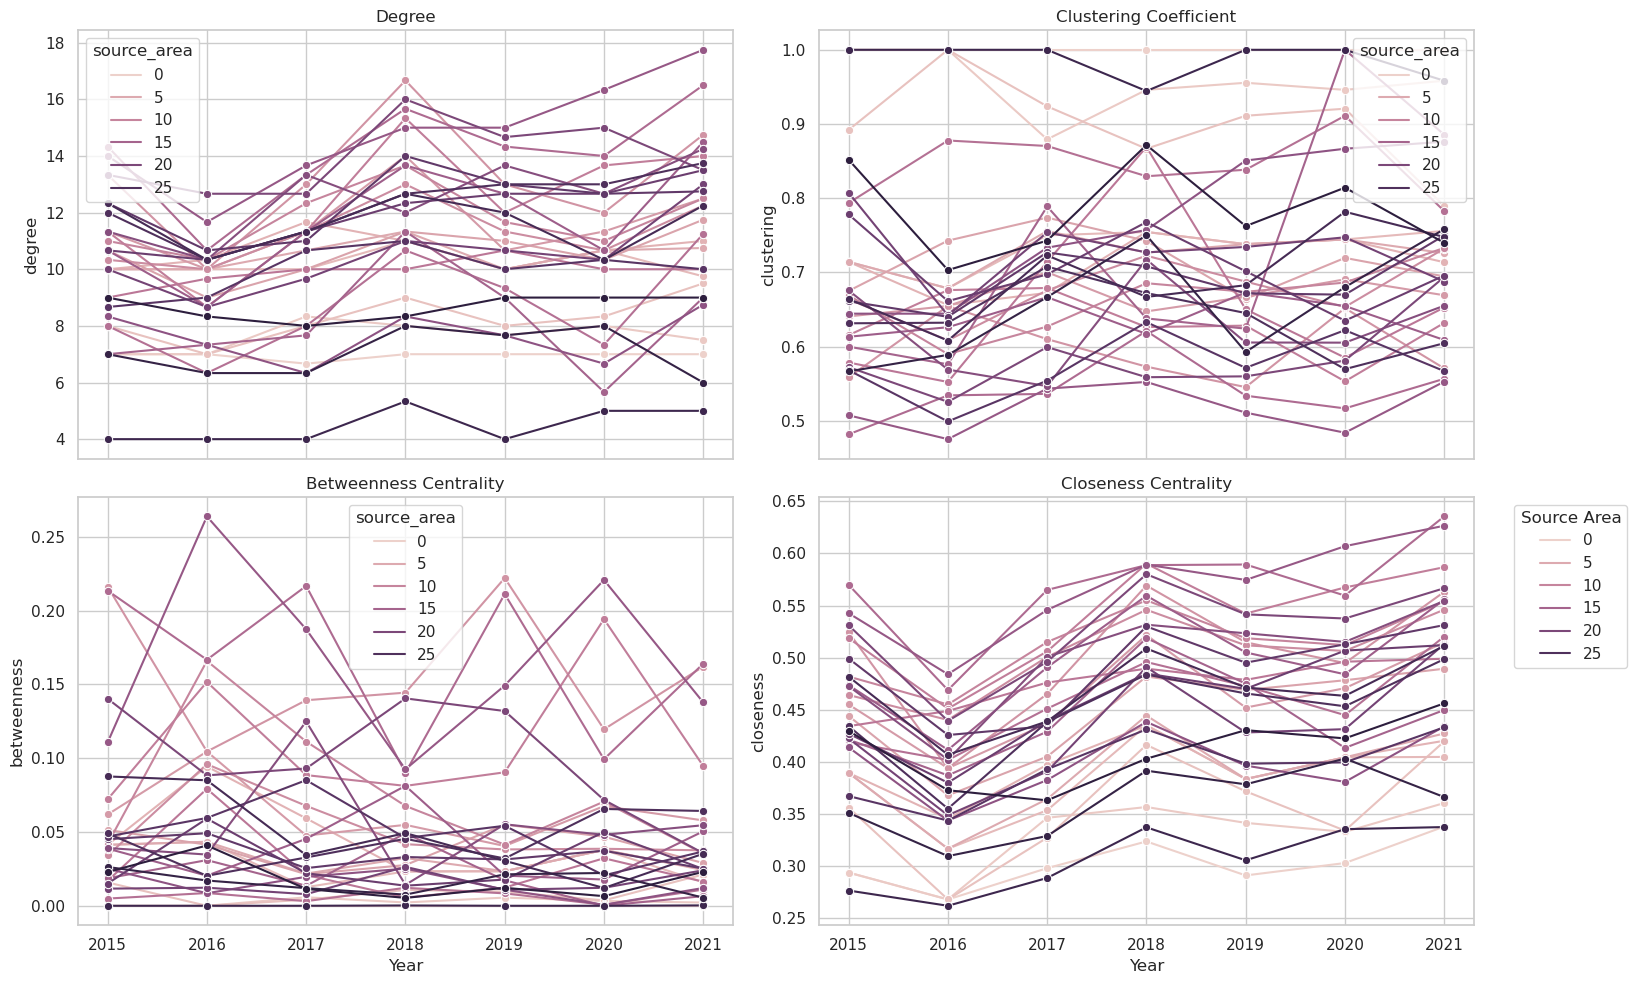

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a figure with 4 subplots (2x2 layout) and shared x-axis
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True)

# Flatten the axis array for easy iteration
axs = axs.flatten()

# Metrics to plot
metrics = ['degree', 'clustering', 'betweenness', 'closeness']
titles = ['Degree', 'Clustering Coefficient', 'Betweenness Centrality', 'Closeness Centrality']

# Plot each metric in a subplot
for i, metric in enumerate(metrics):
    # Use seaborn to plot with hue="source_area"
    sns.lineplot(data=average_metrics_df, x='year', y=metric, hue='source_area', marker='o', ax=axs[i])
    axs[i].set_title(titles[i])
    axs[i].set_ylabel(metric)
    axs[i].set_xlabel('Year')

# Adjust layout
plt.tight_layout()

# Show legend
plt.legend(title='Source Area', bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.show()

## Connectivity metrix by area plots

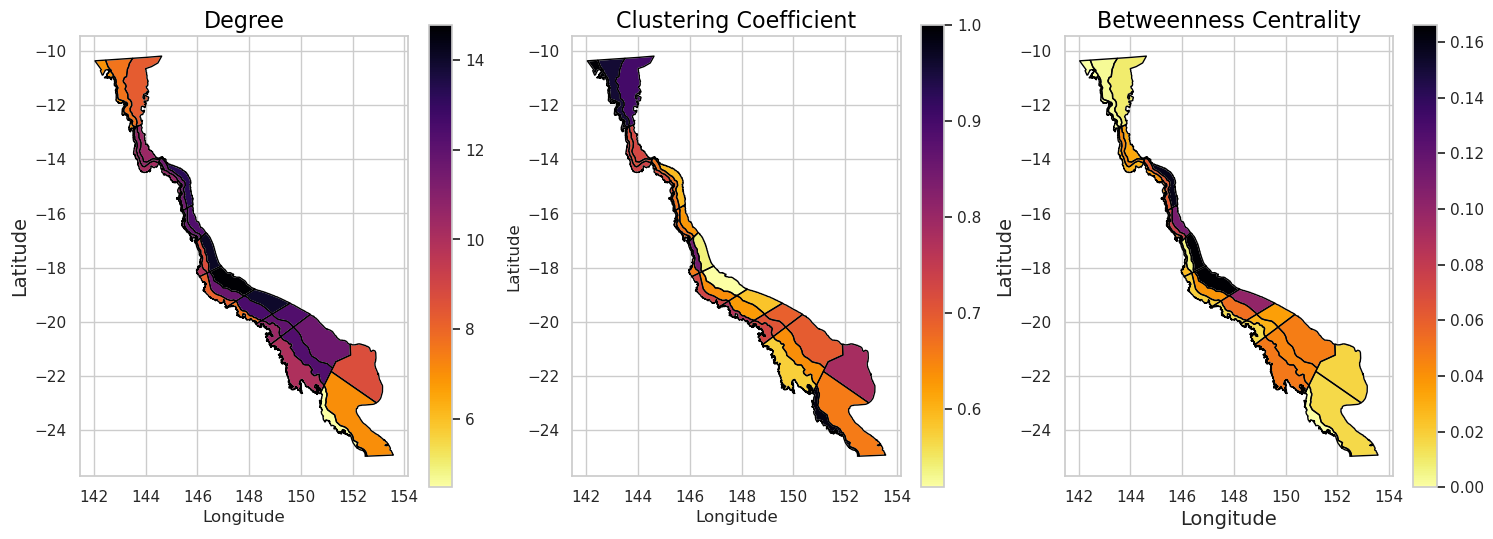

In [16]:
# Ensure 'FID' is of the same type as 'source' in mean_probabilities for a successful merge
gdf4['FID'] = gdf4['FID'].astype(str)
average_metrix_by_area['source_area'] = average_metrix_by_area['source_area'].astype(str)

# Step 2: Merge the GeoDataFrame with mean_probabilities DataFrame
merged_gdf_metrix = gdf4.merge(average_metrix_by_area, left_on='FID', right_on='source_area')

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot the spatial distribution on the first subplot
merged_gdf_metrix.plot(column='degree', cmap='inferno_r', legend=True, ax=axs[0])
axs[0].set_title('Degree', fontsize=16, color='black')
axs[0].set_xlabel('Longitude')  # Remove X-axis label
axs[0].set_ylabel('Latitude', fontsize=14)
merged_gdf.boundary.plot(ax=axs[0], edgecolor='black', linewidth=1)


# Plot the spatial distribution on the second subplot
merged_gdf_metrix.plot(column='clustering', cmap='inferno_r', legend=True, ax=axs[1])
axs[1].set_title('Clustering Coefficient', fontsize=16, color='black')
axs[1].set_xlabel('Longitude')  # Remove X-axis label
axs[1].set_ylabel('Latitude')  # Remove Y-axis label
merged_gdf.boundary.plot(ax=axs[1], edgecolor='black', linewidth=1)

# Plot the spatial distribution on the third subplot
merged_gdf_metrix.plot(column='betweenness', cmap='inferno_r', legend=True, ax=axs[2])
axs[2].set_title('Betweenness Centrality', fontsize=16, color='black')
axs[2].set_xlabel('Longitude', fontsize=14)
axs[2].set_ylabel('Latitude', fontsize=14)
merged_gdf.boundary.plot(ax=axs[2], edgecolor='black', linewidth=1)

## save plot
plt.savefig(f'../outputs/network_metrics_over_time.png')


# Kernel and analysis
## Kernels Calculation
The kernels are estimations of the direction of the main source of larvae (see figure 1). To achieve this, the following steps are necessary:

1. Divide all the possible connections for each sink into 36 possible directions of connections at 10-degree angles, starting from 0 degrees.

2. Calculate the bandwidth (DS) of the kernel, which is determined by the degrees of the location of the main source reefs contributing to the connectivity. This is done by selecting the two main sources of connectivity and adding more adjacent sectors until at least 80% of the total connectivity arrives at that sink reef.

3. Calculate the central direction of the connection (S), which is the central angle for each kernel (central value of the bandwidth).

4. Calculate the distance between the sink and source reef (R), which is a weighted average of the relative contribution of each source reef.

More details on the calculation of these kernels are explained in the code.


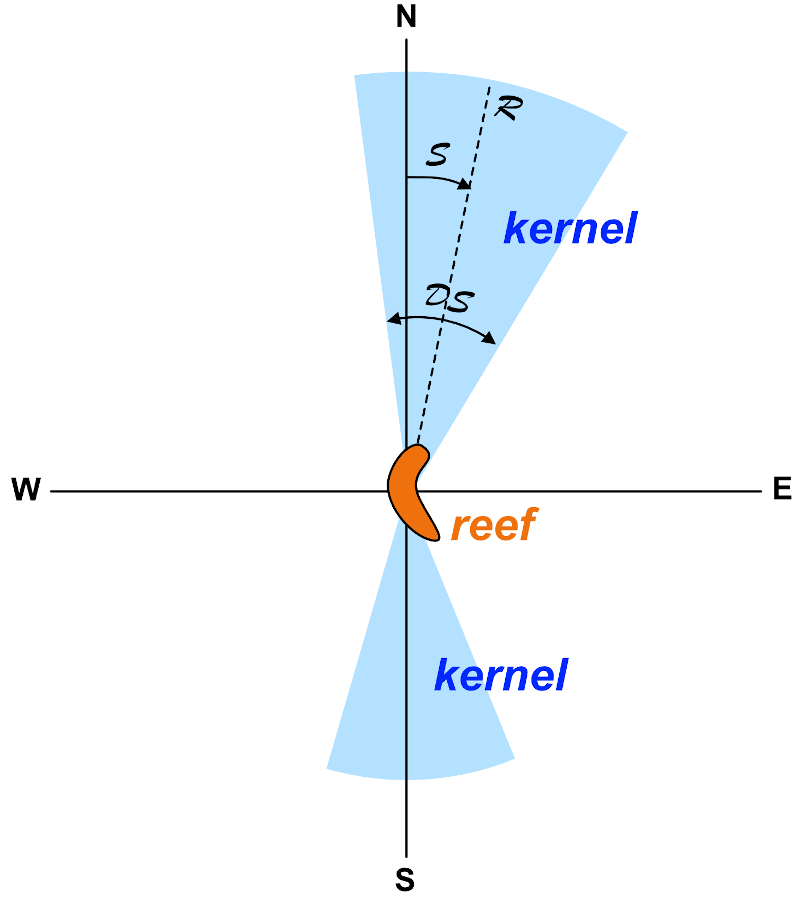

Figure 1: Schematic of the connectivity Kernel calculations

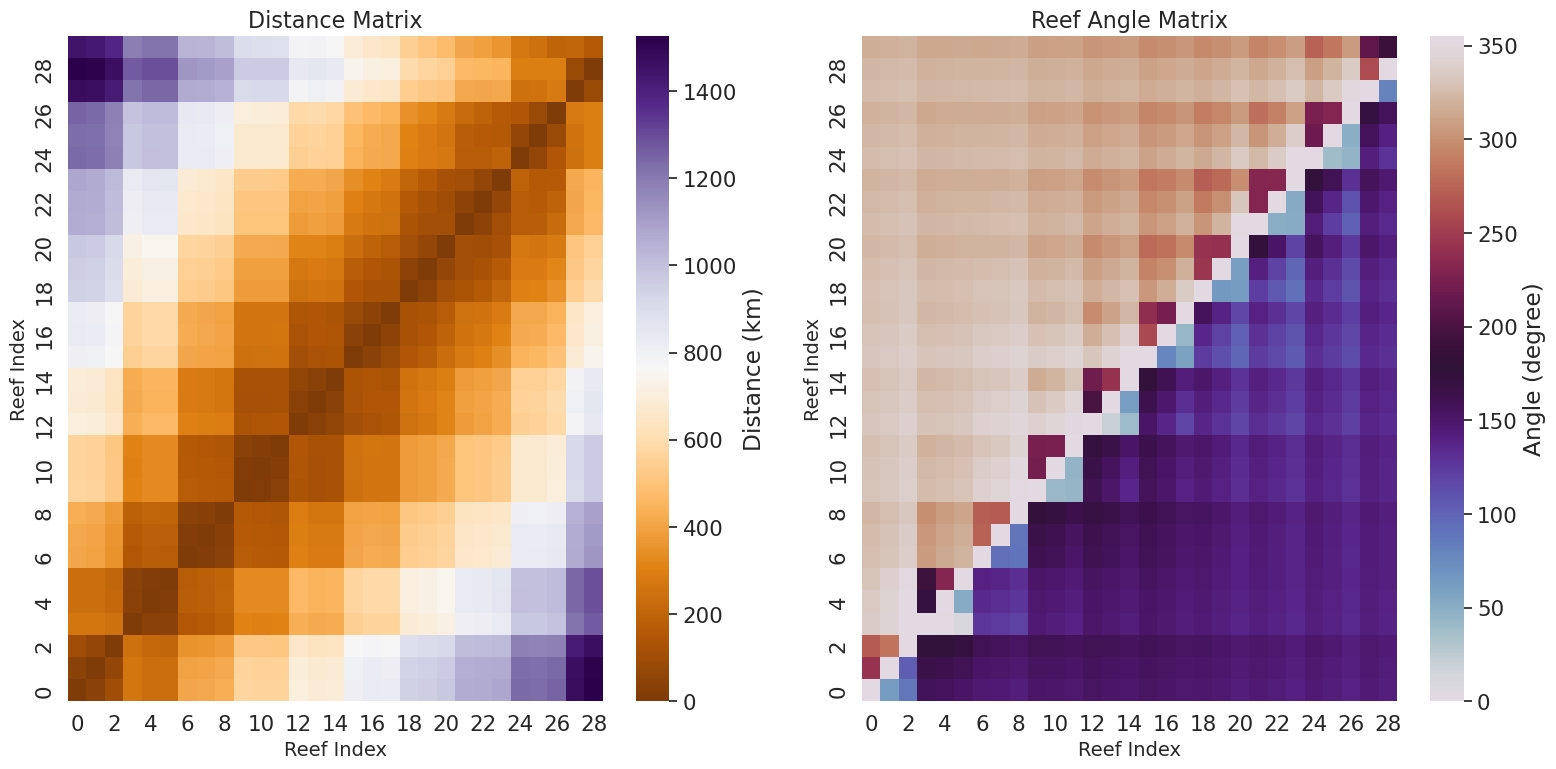

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Increase the base font size using seaborn
sns.set_context("notebook", font_scale=1.4)  # Adjusts the font scale for the context

# Step 2: Load distance and angle matrices
distance_matrix = np.loadtxt('../outputs/GBR_zones_distance.csv', delimiter=',', skiprows=1, usecols=range(1, 30))
angle_matrix = np.loadtxt('../outputs/GBR_zones_angles.csv', delimiter=',', skiprows=1, usecols=range(1, 30))

## flip the matrices 
distance_matrix_flipped = np.flipud(distance_matrix)
angle_matrix_flipped = np.flipud(angle_matrix)

# Assuming `average_connectivity_matrix` is defined somewhere above this excerpt
n_rows, n_cols = distance_matrix.shape  # Adjusted to use distance_matrix for shape

# Plot the distance matrix and ordered distance matrix
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Plot the distance matrix
# Plot the distance matrix
sns.heatmap(distance_matrix, ax=axs[0], cmap='PuOr', cbar_kws={'label': 'Distance (km)'})
axs[0].set_title('Distance Matrix', fontsize=16)  # Set specific font size for title
axs[0].set_xlabel('Reef Index', fontsize=14)  # Set specific font size for xlabel
axs[0].set_ylabel('Reef Index', fontsize=14)  # Set specific font size for ylabel
axs[0].set_xlim(0, n_cols)
axs[0].set_ylim(0, n_rows)

# Plot the ordered distance matrix
sns.heatmap(angle_matrix, ax=axs[1], cmap='twilight', cbar_kws={'label': 'Angle (degree)'})
axs[1].set_title('Reef Angle Matrix', fontsize=16)  # Set specific font size for title
axs[1].set_xlabel('Reef Index', fontsize=14)  # Set specific font size for xlabel
axs[1].set_ylabel('Reef Index', fontsize=14)  # Set specific font size for ylabel
axs[1].set_xlim(0, n_cols)
axs[1].set_ylim(0, n_rows)

plt.tight_layout()
#save
plt.savefig(f'../outputs/distance_matrices.png')


['/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2015-10-29Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2015-11-28Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2015-12-27Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2016-10-18Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2016-11-17Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2016-12-16Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2017-10-08Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kerne

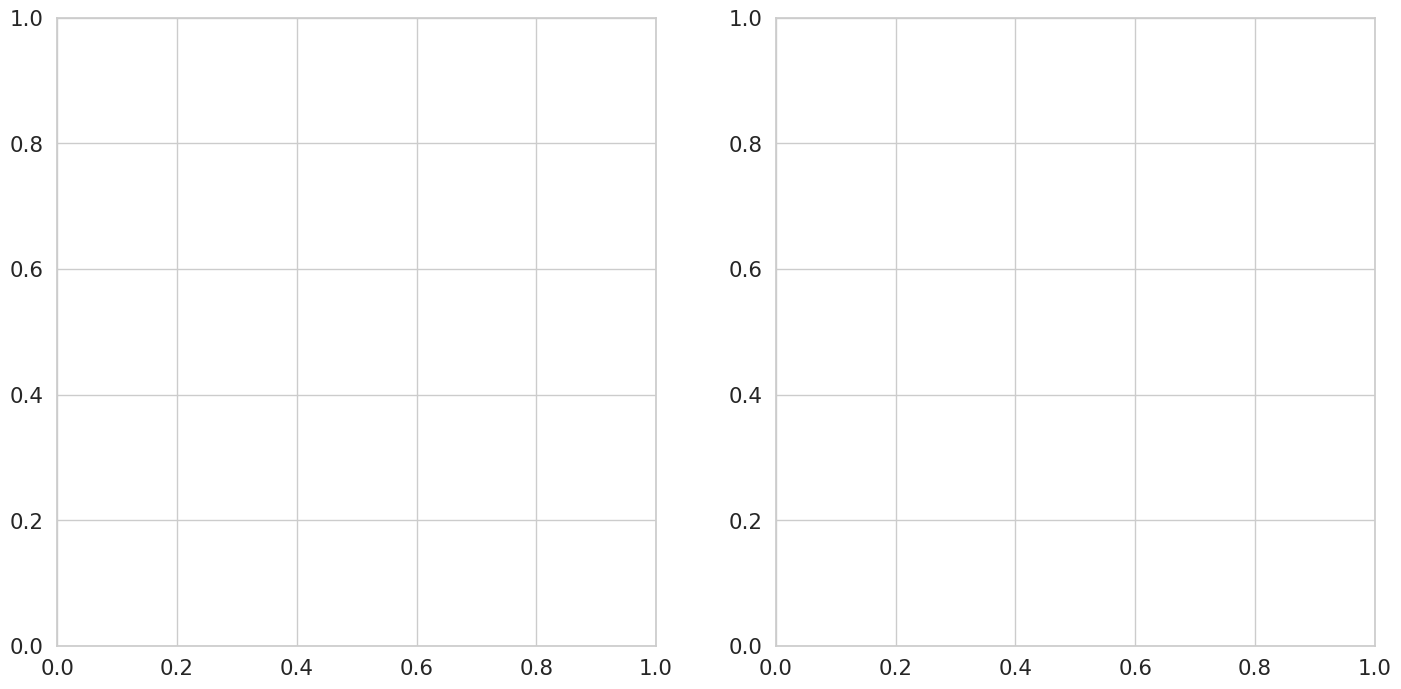

In [18]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from matplotlib.patches import Polygon
## read kernel csv file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

def plot_kernel(ax, lat, lon, angle, width, distance, kernel_connectivity, total_connectivity, col_centroid='b',sink=True):
    # Normalize the kernel_connectivity ratio for better color differentiation
    normalized_ratio = (kernel_connectivity - min_kernel_connectivity) / (max_kernel_connectivity - min_kernel_connectivity)
        # Use the inferno color palette for sinks and twilight_shifted for sources
    color1 = cm.Blues(normalized_ratio)
    color2 = cm.Oranges(normalized_ratio)
    
    # Choose color based on sink or source
    color = color1 if sink else color2
    # Define points of the polygon
    # Convert angle and width to radians
    angle_rad = np.radians(angle)
    width_rad = np.radians(width)    
    distance_deg_lat = distance / 111 
    distance_deg_lon = distance / (111 * np.cos(lat))
    
    # Calculate direction vectors for the two edges of the cone
    dx1 = distance_deg_lat * np.cos(angle_rad - width_rad / 2)
    dy1 = distance_deg_lat * np.sin(angle_rad - width_rad / 2)
    dx2 = distance_deg_lat * np.cos(angle_rad + width_rad / 2)
    dy2 = distance_deg_lat * np.sin(angle_rad + width_rad / 2)    
    points = [
        (lon, lat),  # Starting point (cone base)
        (lon + dx1, lat + dy1),  # First edge endpoint
        (lon + dx2, lat + dy2),  # Second edge endpoint
    ]    
    
    # Create a polygon and add it to the plot
    polygon = Polygon(points, closed=True, color=color, alpha=1)
    ax.add_patch(polygon)
    
    # Add centroid
    # Add centroid if a color is specified
    if col_centroid is not None:
        ax.plot(lon, lat, 'o', color=col_centroid, markersize=10)



# Plot the shapefile
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(17, 10))


# Load the kernel density data
## get all the files in the folder with this name pattern '*._sink.csv'
folder = '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/'

import os
import glob
import pandas as pd

# get all the files in the folder with this name '*._sink.csv'
files_sink = sorted(glob.glob(folder + '*_sink.csv'))
print(files_sink)
# get all the files in the folder with this name '*._source.csv'
files_source = sorted(glob.glob(folder + '*_source.csv'))

for f in range(len(files_sink)):
    filename=files_sink[f][-43:-33]
    kernel_df_sink = pd.read_csv(files_sink[f])
    kernel_df_source = pd.read_csv(files_source[f])

    gdf4.boundary.plot(ax=ax1, color='black', linewidth=1.5, label='Simplified LTMS AIMS')

    # Plot each kernel
    total_connectivity = kernel_df_source['S_sector_01'].sum() + kernel_df_source['S_sector_02'].sum()
    min_kernel_connectivity = min(kernel_df_source['S_sector_01'].min(), kernel_df_source['S_sector_02'].min())
    max_kernel_connectivity = max(kernel_df_source['S_sector_01'].max(), kernel_df_source['S_sector_02'].max())
    for index, row in kernel_df_source.iterrows():
        kernel_connectivity = row['S_sector_01'] + row['S_sector_02']
        ## if Distance_sector_01 is 0 the use the the second kernel
        if row['Distance_sector_01'] == 0:
            plot_kernel(ax1, row['lat'], row['lon'], row['S_sector_02'], row['DS_sector_02'], row['Distance_sector_02'], kernel_connectivity, total_connectivity,col_centroid=None,sink=False)
        else:
            plot_kernel(ax1, row['lat'], row['lon'], row['S_sector_01'], row['DS_sector_01'], row['Distance_sector_01'], kernel_connectivity, total_connectivity,col_centroid='black', sink=False)

    # Adjust the plot limits to the bounds of your shapefile or data points
    ax1.set_xlim([gdf4.bounds.minx.min(), gdf4.bounds.maxx.max()])
    ax1.set_ylim([gdf4.bounds.miny.min(), gdf4.bounds.maxy.max()])
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.set_title('Source Kernel')

    # Plot each kernel
    gdf4.boundary.plot(ax=ax2, color='black', linewidth=1.5, label='Simplified LTMS AIMS')
    total_connectivity = kernel_df_sink['connectivity_sector_01'].sum() + kernel_df_sink['connectivity_sector_02'].sum()
    min_kernel_connectivity = min(kernel_df_sink['connectivity_sector_01'].min(), kernel_df_sink['connectivity_sector_02'].min())
    max_kernel_connectivity = max(kernel_df_sink['connectivity_sector_01'].max(), kernel_df_sink['connectivity_sector_02'].max())
    for index, row in kernel_df_sink.iterrows():
        kernel_connectivity = row['connectivity_sector_01'] + row['connectivity_sector_02']
        ## if Distance_sector_01 is 0 the use the the second kernel
        if row['Distance_sector_01'] == 0:
            plot_kernel(ax2, row['lat'], row['lon'], row['S_sector_02'], row['DS_sector_02'], row['Distance_sector_02'], kernel_connectivity, total_connectivity,col_centroid=None)
        else:
            plot_kernel(ax2, row['lat'], row['lon'], row['S_sector_01'], row['DS_sector_01'], row['Distance_sector_01'], kernel_connectivity, total_connectivity,col_centroid='black')



    # Adjust the plot limits to the bounds of your shapefile or data points
    ax2.set_xlim([gdf4.bounds.minx.min(), gdf4.bounds.maxx.max()])
    ax2.set_ylim([gdf4.bounds.miny.min(), gdf4.bounds.maxy.max()])
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.set_title('Sink Kernel')
    ax2.text(0.95, 0.95, filename, transform=ax2.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=24, color='red')

    # save the figure
    plt.savefig(f'../outputs/kernel_{f}.png')
    # Clear the plots for the next iteration
    ax1.cla()
    ax2.cla()



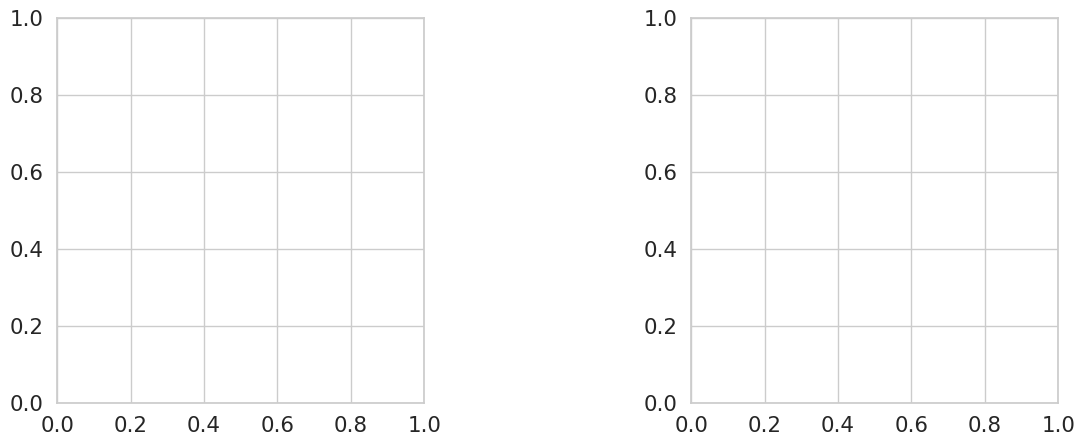

In [19]:
# Plot the shapefile
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))


# Load the kernel density data
## get all the files in the folder with this name pattern '*._sink.csv'
folder = '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/'

import os
import glob
import pandas as pd

# get all the files in the folder with this name '*._sink.csv'
files_sink = sorted(glob.glob(folder + '*_sink.csv'))

# get all the files in the folder with this name '*._source.csv'
files_source = sorted(glob.glob(folder + '*_source.csv'))
selected_poly=17
for f in range(len(files_sink)):
    filename=files_sink[f][-43:-33]
    kernel_df_sink = pd.read_csv(files_sink[f])
    kernel_df_source = pd.read_csv(files_source[f])

    gdf4.boundary.plot(ax=ax1, color='darkblue', linewidth=1.5, label='Simplified LTMS AIMS')

    # Plot each kernel
    total_connectivity = kernel_df_source['S_sector_01'].sum() + kernel_df_source['S_sector_02'].sum()
    min_kernel_connectivity = min(kernel_df_source['S_sector_01'].min(), kernel_df_source['S_sector_02'].min())
    max_kernel_connectivity = max(kernel_df_source['S_sector_01'].max(), kernel_df_source['S_sector_02'].max())
    for index, row in kernel_df_source.iterrows():
        if(index == selected_poly):
            kernel_connectivity = row['S_sector_01'] + row['S_sector_02']
            ## if Distance_sector_01 is 0 the use the the second kernel
            if row['Distance_sector_01'] == 0:
                plot_kernel(ax1, row['lat'], row['lon'], row['S_sector_02'], row['DS_sector_02'], row['Distance_sector_02'], kernel_connectivity, total_connectivity,col_centroid=None,sink=False)
            else:
                plot_kernel(ax1, row['lat'], row['lon'], row['S_sector_01'], row['DS_sector_01'], row['Distance_sector_01'], kernel_connectivity, total_connectivity,col_centroid='black', sink=False)

    # Adjust the plot limits to the bounds of your shapefile or data points
    # ax1.set_xlim([gdf4.bounds.minx.min(), gdf4.bounds.maxx.max()])
    # ax1.set_ylim([gdf4.bounds.miny.min(), gdf4.bounds.maxy.max()])
    ax1.set_xlim([144, 150])
    ax1.set_ylim([-20, -16])
    ax1.set_xlabel('Longitude')
    ax1.set_ylabel('Latitude')
    ax1.set_title('Source Kernel')

    # Plot each kernel
    gdf4.boundary.plot(ax=ax2, color='darkblue', linewidth=1.5, label='Simplified LTMS AIMS')
    total_connectivity = kernel_df_sink['connectivity_sector_01'].sum() + kernel_df_sink['connectivity_sector_02'].sum()
    min_kernel_connectivity = min(kernel_df_sink['connectivity_sector_01'].min(), kernel_df_sink['connectivity_sector_02'].min())
    max_kernel_connectivity = max(kernel_df_sink['connectivity_sector_01'].max(), kernel_df_sink['connectivity_sector_02'].max())
    for index, row in kernel_df_sink.iterrows():
        if(index==selected_poly):
            kernel_connectivity = row['connectivity_sector_01'] + row['connectivity_sector_02']
            ## if Distance_sector_01 is 0 the use the the second kernel
            if row['Distance_sector_01'] == 0:
                plot_kernel(ax2, row['lat'], row['lon'], row['S_sector_02'], row['DS_sector_02'], row['Distance_sector_02'], kernel_connectivity, total_connectivity,col_centroid=None)
            else:
                plot_kernel(ax2, row['lat'], row['lon'], row['S_sector_01'], row['DS_sector_01'], row['Distance_sector_01'], kernel_connectivity, total_connectivity, col_centroid='black')
    # Adjust the plot limits to the bounds of your shapefile or data points
    ax2.set_xlim([144, 150])
    ax2.set_ylim([-20, -16])
    #ax2.set_xlim([gdf4.bounds.minx.min(), gdf4.bounds.maxx.max()])
    #ax2.set_ylim([gdf4.bounds.miny.min(), gdf4.bounds.maxy.max()])
    ax2.set_xlabel('Longitude')
    ax2.set_ylabel('Latitude')
    ax2.set_title('Sink Kernel')
    ax2.text(0.95, 0.95, filename, transform=ax2.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=24, color='red')
    # save the figure
    plt.savefig(f'../outputs/kernel_2_{f}.png')
    # Clear the plots for the next iteration
    ax1.cla()
    ax2.cla()

#Testing angles

In [27]:
import pandas as pd
import numpy as np

# Initialize an empty DataFrame to store the results
weighted_sums_df = pd.DataFrame(columns=['filename', 'S_avg', 'Distance_avg'])
source_df=[]
sink_df=[]
print(files_sink)
for f in range(len(files_sink)):
    filename = files_sink[f][-43:-33]
    kernel_df_source = pd.read_csv(files_source[f], usecols=['reef_ID','S_sector_01','S_sector_02','connectivity_sector_01',
    'connectivity_sector_02','Distance_sector_01', 'Distance_sector_02'])
    kernel_df_sink = pd.read_csv(files_sink[f], usecols=['reef_ID','S_sector_01','S_sector_02','connectivity_sector_01',
    'connectivity_sector_02','Distance_sector_01', 'Distance_sector_02'])
    kernel_df_source['file_name']=filename
    kernel_df_sink['file_name']=filename
    source_df.append(kernel_df_source)
    sink_df.append(kernel_df_sink)
# Correct approach to iterate over rows in the aggregated DataFrame
source_df_concat = pd.concat(source_df)  # Concatenate all DataFrames in the list into a single DataFrame
sink_df_concat = pd.concat(sink_df)  # Concatenate all DataFrames in the list into a single DataFrame

S_results = []
DS_results = []
total_connect = []
for index, row in source_df_concat.iterrows():
    total_connectivity = row['connectivity_sector_01'] + row['connectivity_sector_02']
    if total_connectivity > 0:
        S_avg = ((row['S_sector_01'] * row['connectivity_sector_01']) + 
                 (row['S_sector_02'] * row['connectivity_sector_02'])) / total_connectivity
        Distance_avg = ((row['Distance_sector_01'] * row['connectivity_sector_01']) + 
                        (row['Distance_sector_02'] * row['connectivity_sector_02'])) / total_connectivity
    else:
        S_avg = 0
        Distance_avg = 0
    S_results.append(S_avg)
    DS_results.append(Distance_avg)
    total_connect.append(total_connectivity)
# Add the results to the DataFrame
source_df_concat['source_S_avg'] = S_results
source_df_concat['source_Distance_avg'] = DS_results
source_df_concat['source_total_connectivity'] = total_connect

S_results = []
DS_results = []
total_connect = []
for index, row in sink_df_concat.iterrows():
    total_connectivity = row['connectivity_sector_01'] + row['connectivity_sector_02']
    if total_connectivity > 0:
        S_avg = ((row['S_sector_01'] * row['connectivity_sector_01']) + 
                 (row['S_sector_02'] * row['connectivity_sector_02'])) / total_connectivity
        Distance_avg = ((row['Distance_sector_01'] * row['connectivity_sector_01']) + 
                        (row['Distance_sector_02'] * row['connectivity_sector_02'])) / total_connectivity
    else:
        S_avg = 0
        Distance_avg = 0
    S_results.append(S_avg)
    DS_results.append(Distance_avg)
    total_connect.append(total_connectivity)
sink_df_concat['sink_S_avg'] = S_results
sink_df_concat['sink_Distance_avg'] = DS_results
sink_df_concat['sink_total_connectivity'] = total_connect
# Function to calculate weighted mean excluding NaNs

import numpy as np

import numpy as np
import pandas as pd

# Function to calculate weighted mean excluding NaNs
def weighted_mean(values, weights):
    # Filter out NaNs from both values and weights
    mask = ~np.isnan(values) & ~np.isnan(weights)
    filtered_values = values[mask]
    filtered_weights = weights[mask]
    if len(filtered_values) == 0:  # Check if all values were NaN
        return np.nan  # Return NaN if there are no valid entries to calculate mean
    return np.average(filtered_values, weights=filtered_weights)

# Assuming source_df_concat is your DataFrame from the previous steps
# Ensure NaNs are handled by excluding them in the groupby operation
weighted_means_source = source_df_concat.groupby('reef_ID').apply(
    lambda x: pd.Series({
        'weighted_S_avg_sink': weighted_mean(x['source_S_avg'], x['source_total_connectivity']),
        'weighted_Distance_avg_sink': weighted_mean(x['source_Distance_avg'], x['source_total_connectivity'])
    })
).reset_index()

weighted_means_source['reef_ID']=weighted_means_source['reef_ID'].astype(str)

# Assuming sink_df_concat is your DataFrame from the previous steps
# Ensure NaNs are handled by excluding them in the groupby operation
weighted_means_sink = sink_df_concat.groupby('reef_ID').apply(
    lambda x: pd.Series({
        'weighted_S_avg_source': weighted_mean(x['sink_S_avg'], x['sink_total_connectivity']),
        'weighted_Distance_avg_source': weighted_mean(x['sink_Distance_avg'], x['sink_total_connectivity'])
    })
).reset_index()

weighted_means_sink['reef_ID']=weighted_means_sink['reef_ID'].astype(str)
print(weighted_means_sink)


['/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2015-10-29Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2015-11-28Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2015-12-27Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2016-10-18Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2016-11-17Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2016-12-16Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kernels/2017-10-08Kernel_parameters_Corals_sink.csv', '/home/por07g/Documents/Projects/GBR_modeling/Connectivity_analysis/datasets/Kerne

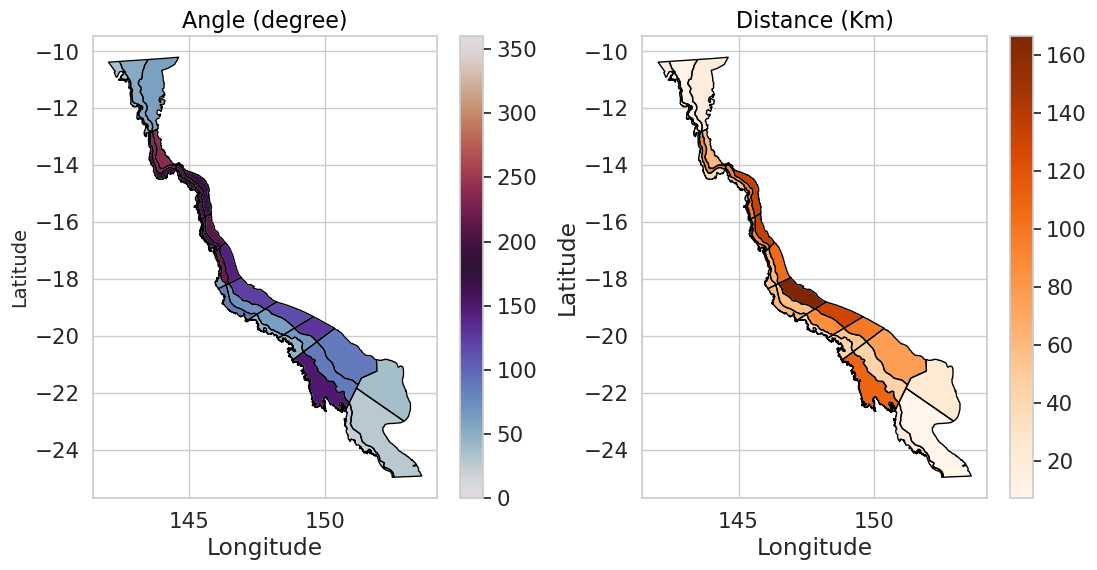

In [37]:
merged_results = gdf4.merge(weighted_means_source, left_on='FID', right_on='reef_ID')
merged_results = merged_results.merge(weighted_means_sink, left_on='FID', right_on='reef_ID')

fig, axs = plt.subplots(1, 2, figsize=(13, 6))

# Plot the spatial distribution on the first subplot
merged_results.plot(column='weighted_S_avg_source', cmap='twilight', vmin=0, vmax=360,legend=True, ax=axs[0])
axs[0].set_title('Angle (degree)', fontsize=16, color='black')
axs[0].set_xlabel('Longitude')  # Remove X-axis label
axs[0].set_ylabel('Latitude', fontsize=14)
merged_gdf.boundary.plot(ax=axs[0], edgecolor='black', linewidth=1)


# Plot the spatial distribution on the second subplot
merged_results.plot(column='weighted_Distance_avg_source', cmap='Oranges', legend=True, ax=axs[1])
axs[1].set_title('Distance (Km)', fontsize=16, color='black')
axs[1].set_xlabel('Longitude')  # Remove X-axis label
axs[1].set_ylabel('Latitude')  # Remove Y-axis label
merged_gdf.boundary.plot(ax=axs[1], edgecolor='black', linewidth=1)

# # Plot the spatial distribution on the third subplot
# merged_results.plot(column='weighted_Distance_avg_sink', cmap='inferno_r', legend=True, ax=axs[2])
# axs[2].set_title('Betweenness Centrality', fontsize=16, color='black')
# axs[2].set_xlabel('Longitude', fontsize=14)
# axs[2].set_ylabel('Latitude', fontsize=14)
# merged_gdf.boundary.plot(ax=axs[2], edgecolor='black', linewidth=1)

## save plot
plt.savefig(f'../outputs/Kernel_source_avg.png')
# Display the resulting DataFrame


In [ ]:
# reading csv of angles between polygons
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Step 2: Load distance and angle matrices
distance_matrix = np.loadtxt('../outputs/GBR_zones_distance.csv',
                             delimiter=',', skiprows=1, usecols=range(1, len(reef_order)+1))
angle_matrix = np.loadtxt('../outputs/GBR_zones_angles.csv',
                          delimiter=',', skiprows=1, usecols=range(1, len(reef_order)+1))

# Plot the distance matrix and ordered distance matrix
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

# Plot the distance matrix
sns.heatmap(distance_matrix, ax=axs[0], cmap='viridis', cbar_kws={'label': 'Distance (km)'})
axs[0].set_title('Distance Matrix')
axs[0].set_xlabel('Reef Index')
axs[0].set_ylabel('Reef Index')

# Plot the ordered distance matrix
sns.heatmap(angle_matrix, ax=axs[1], cmap='viridis', cbar_kws={'label': 'Distance (km)'})
axs[1].set_title('Ordered Distance Matrix')
axs[1].set_xlabel('Reef Index')
axs[1].set_ylabel('Reef Index')


NameError: name 'reef_order' is not defined

In [ ]:
# reading csv of angles between polygons
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Step 2: Load distance and angle matrices
distance_matrix = np.loadtxt('../outputs/GBR_zones_distance.csv',
                             delimiter=',', skiprows=1, usecols=range(1, len(reef_order)+1))
angle_matrix = np.loadtxt('../outputs/GBR_zones_angles.csv',
                          delimiter=',', skiprows=1, usecols=range(1, len(reef_order)+1))
kernel_df = pd.read_csv('../Codes/2015-10-29Kernel_parameters_Corals.csv')
# get the lat and lon of the kernel 17 an 28
lat_17 = kernel_df.loc[17, 'lat']
lon_17 = kernel_df.loc[17, 'lon']
lat_28 = kernel_df.loc[28, 'lat']
lon_28 = kernel_df.loc[28, 'lon']

import matplotlib.pyplot as plt
import numpy as np

def calculate_bearing(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Difference in longitude
    dLon = lon2 - lon1
    
    # Calculate bearing
    x = np.sin(dLon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dLon)
    bearing = np.arctan2(x, y)
    
    # Convert bearing from radians to degrees
    bearing = np.degrees(bearing)
    
    # Normalize the bearing to be within 0 to 360 degrees
    bearing = (bearing + 360) % 360
    
    return bearing


## compare the angle and the bearing between the polygons 14-13, 2-20, 17-28
angle_14_13 = angle_matrix[13, 14]
angle_2_20 = angle_matrix[20, 2]
angle_17_28 = angle_matrix[28, 17]
bearing_14_13 = calculate_bearing(kernel_df.loc[13, 'lat'], kernel_df.loc[13, 'lon'], kernel_df.loc[14, 'lat'], kernel_df.loc[14, 'lon'])
bearing_2_20 = calculate_bearing(kernel_df.loc[20, 'lat'], kernel_df.loc[20, 'lon'], kernel_df.loc[2, 'lat'], kernel_df.loc[2, 'lon'])
bearing_17_28 = calculate_bearing(kernel_df.loc[28, 'lat'], kernel_df.loc[28, 'lon'], kernel_df.loc[17, 'lat'], kernel_df.loc[17, 'lon'])

print(f"Angle between polygons 14 and 13: {angle_14_13:.2f} degrees, Bearing: {bearing_14_13:.2f} degrees")
print(f"Angle between polygons 2 and 20: {angle_2_20:.2f} degrees, Bearing: {bearing_2_20:.2f} degrees")
print(f"Angle between polygons 17 and 28: {angle_17_28:.2f} degrees, Bearing: {bearing_17_28:.2f} degrees")


Angle between polygons 14 and 13: 62.12 degrees, Bearing: 61.02 degrees
Angle between polygons 2 and 20: 327.41 degrees, Bearing: 328.31 degrees
Angle between polygons 17 and 28: 316.08 degrees, Bearing: 317.17 degrees
